In [1]:
print("EDA Notebook Ready")


EDA Notebook Ready



Loading the dataset.
The dataset was loaded using the pandas library. Since the original file does not contain column headers, the feature names were manually defined based on the official UCI documentation. Additionally, the dataset contains missing values represented by the symbol "?". These were explicitly converted into proper NaN values during loading to ensure that missing data is correctly recognized by pandas for further analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define column names from UCI documentation
columns = [
    "Class",
    "age",
    "menopause",
    "tumor_size",
    "inv_nodes",
    "node_caps",
    "deg_malig",
    "breast",
    "breast_quad",
    "irradiat"
]

# Load dataset (IMPORTANT: handle missing values marked as '?')
df = pd.read_csv(
    "../data/raw/breast-cancer.data",
    header=None,
    names=columns,
    na_values="?"
)

df.head()


,Class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


EDA:
Understanding dataset structure:
After loading the dataset, the overall structure was examined using .shape() and .info() functions. The dataset contains 286 patient records and 10 columns, including 9 clinical features and 1 target variable indicating recurrence status.

All features are categorical in nature, except for deg_malig, which represents the degree of malignancy and is numeric.

In [3]:
df.shape


(286, 10)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Class        286 non-null    str  
 1   age          286 non-null    str  
 2   menopause    286 non-null    str  
 3   tumor_size   286 non-null    str  
 4   inv_nodes    286 non-null    str  
 5   node_caps    278 non-null    str  
 6   deg_malig    286 non-null    int64
 7   breast       286 non-null    str  
 8   breast_quad  285 non-null    str  
 9   irradiat     286 non-null    str  
dtypes: int64(1), str(9)
memory usage: 22.5 KB


Missing Values:
Missing values were analyzed using .isnull().sum(). The dataset contains missing entries in the node_caps feature, which reflects real-world clinical uncertainty where certain diagnostic details may not be recorded.

In [5]:
df.isnull().sum()


Class          0
age            0
menopause      0
tumor_size     0
inv_nodes      0
node_caps      8
deg_malig      0
breast         0
breast_quad    1
irradiat       0
dtype: int64

In [6]:
(df.isnull().sum() / len(df)) * 100


Class          0.000000
age            0.000000
menopause      0.000000
tumor_size     0.000000
inv_nodes      0.000000
node_caps      2.797203
deg_malig      0.000000
breast         0.000000
breast_quad    0.349650
irradiat       0.000000
dtype: float64

Class Distribution Analysis:
The distribution of the target variable (Class) was examined using .value_counts() and visualized with a count plot. The dataset shows a moderate class imbalance, with significantly more "no-recurrence-events" cases than "recurrence-events".

In [7]:
df["Class"].value_counts()


Class
no-recurrence-events    201
recurrence-events        85
Name: count, dtype: int64

Visualization of Analysis:

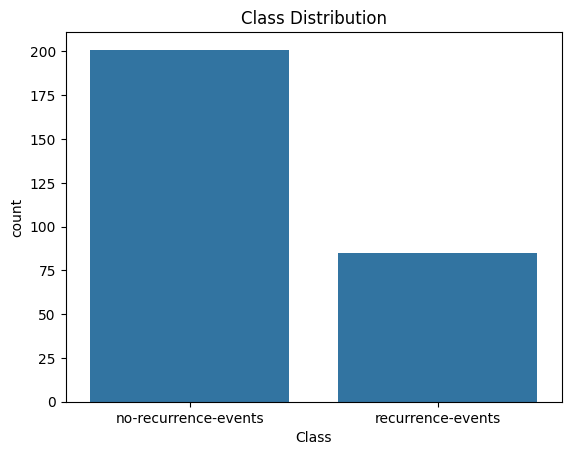

In [8]:
sns.countplot(data=df, x="Class")
plt.title("Class Distribution")
plt.show()


Feature Distribution Analysis:

In [9]:
for col in df.columns[1:]:
    print(f"\n{col}")
    print(df[col].value_counts())



age
age
50-59    96
40-49    90
60-69    57
30-39    36
70-79     6
20-29     1
Name: count, dtype: int64

menopause
menopause
premeno    150
ge40       129
lt40         7
Name: count, dtype: int64

tumor_size
tumor_size
30-34    60
25-29    54
20-24    50
15-19    30
10-14    28
40-44    22
35-39    19
0-4       8
50-54     8
5-9       4
45-49     3
Name: count, dtype: int64

inv_nodes
inv_nodes
0-2      213
3-5       36
6-8       17
9-11      10
15-17      6
12-14      3
24-26      1
Name: count, dtype: int64

node_caps
node_caps
no     222
yes     56
Name: count, dtype: int64

deg_malig
deg_malig
2    130
3     85
1     71
Name: count, dtype: int64

breast
breast
left     152
right    134
Name: count, dtype: int64

breast_quad
breast_quad
left_low     110
left_up       97
right_up      33
right_low     24
central       21
Name: count, dtype: int64

irradiat
irradiat
no     218
yes     68
Name: count, dtype: int64


Visualizations:

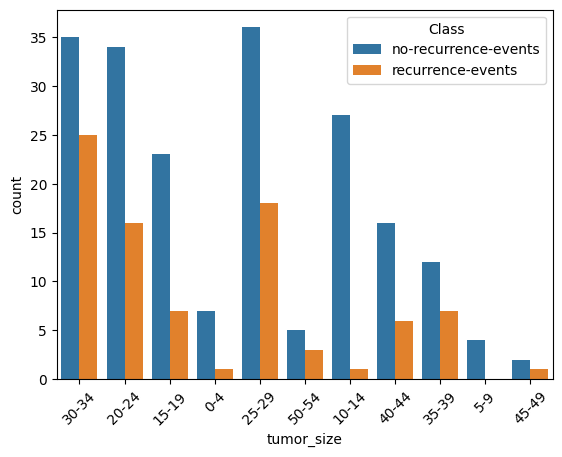

In [10]:
sns.countplot(data=df, x="tumor_size", hue="Class")
plt.xticks(rotation=45)
plt.show()


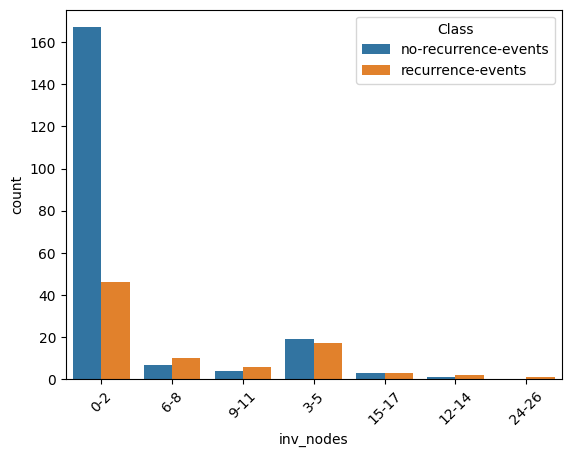

In [11]:
sns.countplot(data=df, x="inv_nodes", hue="Class")
plt.xticks(rotation=45)
plt.show()


Outliers/Unrealistic values:

In [12]:
for col in df.columns:
    print(df[col].unique())


<StringArray>
['no-recurrence-events', 'recurrence-events']
Length: 2, dtype: str
<StringArray>
['30-39', '40-49', '60-69', '50-59', '70-79', '20-29']
Length: 6, dtype: str
<StringArray>
['premeno', 'ge40', 'lt40']
Length: 3, dtype: str
<StringArray>
['30-34', '20-24', '15-19',   '0-4', '25-29', '50-54', '10-14', '40-44',
 '35-39',   '5-9', '45-49']
Length: 11, dtype: str
<StringArray>
['0-2', '6-8', '9-11', '3-5', '15-17', '12-14', '24-26']
Length: 7, dtype: str
<StringArray>
['no', 'yes', nan]
Length: 3, dtype: str
[3 2 1]
<StringArray>
['left', 'right']
Length: 2, dtype: str
<StringArray>
['left_low', 'right_up', 'left_up', 'right_low', 'central', nan]
Length: 6, dtype: str
<StringArray>
['no', 'yes']
Length: 2, dtype: str


Saving Clean Version of Data:

In [13]:
df.to_csv("../data/processed/eda_checked.csv", index=False)


DATASET JUSTIFICATION:

Importance of Uncertainity in this Dataset:
Since real-world data is rarely flawless or clean, uncertainty is crucial in this housing dataset. Missing values, different numerical feature scales, and possible outliers can all cause analysis to become distorted if not managed appropriately. Prediction uncertainty is introduced by features that may not have a perfectly linear relationship with house value, such as median income, total rooms, and housing median age. Furthermore, household-level differences might be obscured by district-level data that has been aggregated. If uncertainty is disregarded, the model might perform well in testing but poorly in practical situations. Consequently, more accurate and reliable forecasts are guaranteed when uncertainty is recognized and controlled.

Need of a system instead of a Model:
A structured system comprising data loading, preprocessing, handling missing values, feature engineering, scaling, and validation prior to modeling was necessary for the project. Even a powerful algorithm would yield unreliable results without adequate preprocessing. Reproducibility, consistency, and equity in forecasts are guaranteed by a system. Additionally, it enables the workflow to effectively manage newly incoming data. As a result, the answer is not merely a model but rather a complete pipeline that converts unprocessed data into accurate and significant predictions.

Data Reality Vs Assumptions:

Initial Assumptions:
Data would be clean and complete.
Classes might be balanced.

Findings:
Missing values detected in node_caps.
Moderate class imbalance (recurrence less frequent).
Some tumor size categories rare.